# Vision-Language Models (VLMs) — In-Class Lab

**Course:** ITAI 1378 · **Duration:** ~75–90 minutes · **Tools:** Google Colab (free GPU)

In this lab you will use two real vision-language models to *see* how images and text
are connected inside a shared embedding space:

1. **CLIP** (OpenAI) — matches images to text. You'll use it for **zero-shot image classification**
   (classifying images into categories the model was *never explicitly trained on*).
2. **BLIP** (Salesforce) — a **generative** VLM. You'll use it to **caption images** and answer
   **questions about images** (VQA).

### Learning objectives
By the end you will be able to:
- Explain how CLIP turns images and text into comparable **embeddings**.
- Build a **zero-shot classifier** from nothing but class names.
- Show that **prompt wording changes accuracy** (prompt engineering).
- Generate captions and answers for an image you upload yourself.

### How to work
- Cells marked **`# TODO`** are for *you* to complete. Everything else you just **run**.
- Run cells top to bottom (`Shift+Enter`).
- Answer the **Reflection questions** at the bottom in the final markdown cell and submit the notebook.

---
### ⚙️ Before you start — turn on the GPU
`Runtime → Change runtime type → Hardware accelerator → T4 GPU → Save`.
Everything runs on CPU too, just slower.


## Part 0 — Setup

Install the libraries and import what we need. This first cell downloads a few packages, so
give it ~30 seconds. `torch` and `PIL` are already installed on Colab.

In [1]:
!pip install -q transformers datasets

In [2]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", device)

def show(img, title=""):
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

Running on: cuda


## Part 1 — Load CLIP

**How CLIP works (the 30-second version):** CLIP has *two* encoders — one for images, one for text.
It was trained on 400M image–caption pairs so that a matching image and caption land at nearly the
**same point** in a shared vector space, while mismatched pairs land far apart. To use it we encode an
image and some candidate texts, then measure **similarity** (a dot product). The closest text "wins".

We use `clip-vit-base-patch32` — the small, fast version (~600 MB download).

In [3]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print("CLIP loaded.")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded.


## Part 2 — Image ↔ text similarity  *(your first TODO)*

Let's build intuition on a single image. We grab one picture from the dataset and ask CLIP:
*"Which of these captions best matches this image?"*

The processor turns text + image into tensors; the model returns `logits_per_image`, a
similarity score for each caption. Apply `softmax` to read them as probabilities.

**TODO:** Fill in the two missing lines so `probs` holds one probability per caption.

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

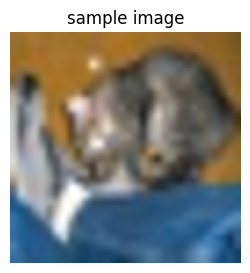

 70.3%  a photo of a cat
  0.8%  a photo of a truck
  0.8%  a photo of an airplane in the sky
 28.1%  a photo of a dog


In [4]:
# We'll reuse this sample image throughout Part 2.
from datasets import load_dataset
_peek = load_dataset("uoft-cs/cifar10", split="test[:1]")
sample_image = _peek[0]["img"].resize((160, 160))   # upscale so it's easier to see
show(sample_image, "sample image")

candidate_captions = [
    "a photo of a cat",
    "a photo of a truck",
    "a photo of an airplane in the sky",
    "a photo of a dog",
]

# TODO 1a: build the model inputs. Pass BOTH the text list and the image.
#          Hint: clip_processor(text=..., images=..., return_tensors="pt", padding=True)
inputs =  clip_processor(
    text=candidate_captions,
    images=sample_image,
    return_tensors="pt",
    padding=True
) # <-- YOUR CODE HERE
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = clip_model(**inputs)

# logits_per_image has shape [1, num_captions]
logits = outputs.logits_per_image

# TODO 1b: convert logits to probabilities across the captions (dim=1)
probs = logits.softmax(dim=1)  # <-- YOUR CODE HERE

for caption, p in zip(candidate_captions, probs[0].tolist()):
    print(f"{p:6.1%}  {caption}")

**Check yourself:** the probabilities should sum to 100% and the highest one should match
what's actually in the picture. Try swapping in your *own* captions above and rerun.

## Part 3 — The dataset: CIFAR-10

**What it is:** CIFAR-10 is a classic benchmark of 60,000 tiny (32×32) colour photos across
**10 everyday categories**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

**Where it comes from:** we stream it straight from the Hugging Face Hub
(`uoft-cs/cifar10`) — no manual download, no signup. We'll use a random **300-image** slice of the
test split so the lab runs in seconds.

Run the cell to load it and preview a few images with their true labels.

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Loaded 300 images.



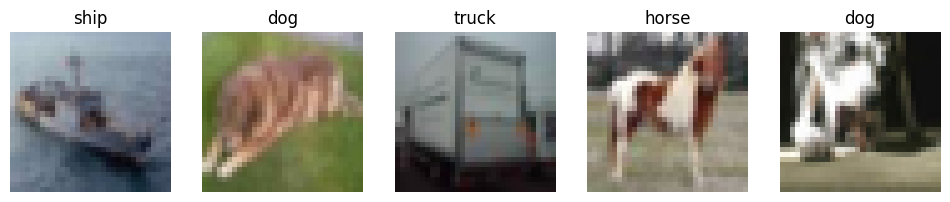

In [5]:
from datasets import load_dataset

N = 300  # sample size — bump to 1000 if you want a sturdier accuracy estimate
full = load_dataset("uoft-cs/cifar10", split="test")
data = full.shuffle(seed=42).select(range(N))

# The image column is called "img" in this dataset (be defensive just in case).
IMG_COL = "img" if "img" in data.column_names else "image"

class_names = data.features["label"].names
print("Classes:", class_names)
print(f"Loaded {len(data)} images.\n")

# Preview 5 images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, ex in zip(axes, data.select(range(5))):
    ax.imshow(ex[IMG_COL]); ax.axis("off")
    ax.set_title(class_names[ex["label"]])
plt.show()

## Part 4 — Zero-shot classification  *(main TODO)*

Here's the key idea: CLIP has **never been trained on CIFAR-10 labels**. Instead we turn each of the
10 class names into a sentence (a *prompt*), encode all 10 once, then for each image pick the class
whose text embedding is **most similar** to the image embedding. That's zero-shot classification.

### Step 1 — Encode the class prompts once (given)
Encoding the 10 prompts a single time (instead of per image) makes the whole loop fast.

In [6]:
PROMPT_TEMPLATE = "a photo of a {}"
prompts = [PROMPT_TEMPLATE.format(c) for c in class_names]
print("Example prompt:", prompts[0])

def encode_text(prompt_list):
    text_inputs = clip_processor(text=prompt_list, return_tensors="pt", padding=True)
    text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
    with torch.no_grad():
        feats = clip_model.get_text_features(**text_inputs)
    return feats.pooler_output / feats.pooler_output.norm(dim=-1, keepdim=True)   # normalize to unit length

text_features = encode_text(prompts)
print("text_features shape:", tuple(text_features.shape))  # -> (10, 512)

Example prompt: a photo of a airplane
text_features shape: (10, 512)


### Step 2 — Classify one image  *(TODO)*
Complete `classify()`. Encode the image, normalize it, then compute similarity against
`text_features` and return the index of the best-matching class.

In [7]:
def classify(image, text_feats):
    # Encode + normalize the image
    image_inputs = clip_processor(images=image, return_tensors="pt")
    image_inputs = {k: v.to(device) for k, v in image_inputs.items()}
    with torch.no_grad():
        img_feats = clip_model.get_image_features(**image_inputs)
    img_feats = img_feats.pooler_output / img_feats.pooler_output.norm(dim=-1, keepdim=True)

    # TODO 2: similarity = dot product between the image feature (1x512)
    #         and every text feature (10x512). Result should be shape [10].
    #         Hint: (img_feats @ text_feats.T).squeeze(0)
    similarities = (img_feats @ text_feats.T).squeeze(0)  # <-- YOUR CODE HERE

    predicted_index = int(similarities.argmax())
    return predicted_index, similarities

# Quick smoke test on one image
idx, sims = classify(data[0][IMG_COL], text_features)
print("Predicted:", class_names[idx], "| True:", class_names[data[0]['label']])

Predicted: ship | True: ship


### Step 3 — Measure accuracy over the whole sample  *(TODO)*
Loop over the 300 images, classify each, and count how many predictions match the true label.

In [8]:
def evaluate(dataset, text_feats):
    correct = 0
    for ex in tqdm(dataset, desc="classifying"):
        pred, _ = classify(ex[IMG_COL], text_feats)
        # TODO 3: increment `correct` when the prediction matches ex["label"]
        if pred == ex["label"]:
          correct += 1  # <-- YOUR CODE HERE (replace this line)
    return correct / len(dataset)

accuracy = evaluate(data, text_features)
print(f"\nZero-shot accuracy: {accuracy:.1%}")

classifying:   0%|          | 0/300 [00:00<?, ?it/s]


Zero-shot accuracy: 90.3%


> **What to expect:** with the `"a photo of a {}"` prompt you should see roughly **85–90%**.
> Not bad for a model that never saw a single CIFAR training label!

### Step 4 — Look at the mistakes (given)
Understanding *where* it fails is more useful than the single accuracy number.

29 misclassified out of 300


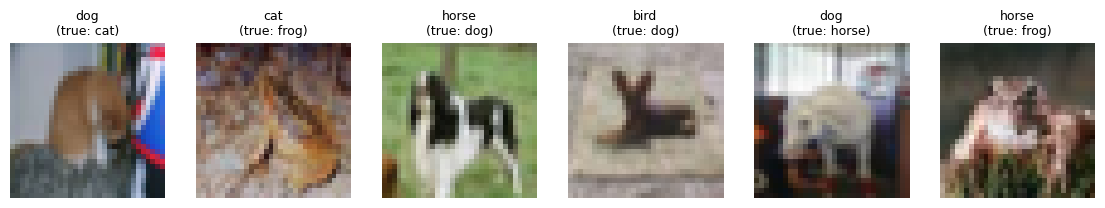

In [9]:
wrong = []
for ex in data:
    pred, _ = classify(ex[IMG_COL], text_features)
    if pred != ex["label"]:
        wrong.append((ex, pred))

print(f"{len(wrong)} misclassified out of {len(data)}")

# Show up to 6 mistakes: title = "pred / true"
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, (ex, pred) in zip(axes, wrong[:6]):
    ax.imshow(ex[IMG_COL]); ax.axis("off")
    ax.set_title(f"{class_names[pred]}\n(true: {class_names[ex['label']]})", fontsize=9)
plt.show()

## Part 5 — Prompt engineering  *(TODO)*

The *only* text CLIP sees is your prompt, so wording matters. Compare a few templates and see how
accuracy shifts. **TODO:** add at least one template of your own to the list, run the cell, and
**write down the numbers** for the Reflection section.

In [10]:
templates = [
    "{}",                       # bare class name
    "a photo of a {}",          # the classic CLIP prompt
    "a blurry low-resolution photo of a {}",
    "a close-up photo of a {}",
    "a high quality photo of a {}"
    # TODO 4: add one or two of your OWN templates below, e.g. "a picture of a {} on a plain background"
]

results = {}
for tmpl in templates:
    feats = encode_text([tmpl.format(c) for c in class_names])
    acc = evaluate(data, feats)
    results[tmpl] = acc

print("\n=== Prompt comparison ===")
for tmpl, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f'{acc:6.1%}   \"{tmpl}"')

classifying:   0%|          | 0/300 [00:00<?, ?it/s]

classifying:   0%|          | 0/300 [00:00<?, ?it/s]

classifying:   0%|          | 0/300 [00:00<?, ?it/s]

classifying:   0%|          | 0/300 [00:00<?, ?it/s]

classifying:   0%|          | 0/300 [00:00<?, ?it/s]


=== Prompt comparison ===
 90.7%   "a blurry low-resolution photo of a {}"
 90.7%   "a high quality photo of a {}"
 90.3%   "a photo of a {}"
 89.3%   "a close-up photo of a {}"
 87.7%   "{}"


## Part 6 — Image captioning with BLIP (a generative VLM)

CLIP *matches* text to images. BLIP can **write** text about an image. Let's load BLIP and caption
an image **you** choose.

First load the model (~1 GB download).

In [11]:
from transformers import BlipProcessor, BlipForConditionalGeneration

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base").to(device)

def caption(image):
    inputs = blip_processor(image, return_tensors="pt").to(device)
    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=30)
    return blip_processor.decode(out[0], skip_special_tokens=True)

print("BLIP captioning model loaded.")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BLIP captioning model loaded.


### Upload your own image
Run the cell below and pick any photo from your computer. *(Not on Colab? Skip the upload and set
`my_image = Image.open("path/to/your.jpg").convert("RGB")` instead.)*

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Saving My_cat.jpeg to My_cat.jpeg


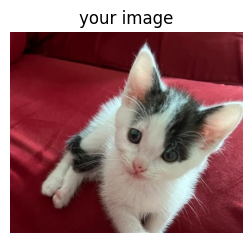

BLIP caption: a kitten is sitting on a red couch


In [12]:
try:
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))
    my_image = Image.open(fname).convert("RGB")
except Exception as e:
    print("Colab upload unavailable — set my_image manually. Details:", e)
    # my_image = Image.open("your_image.jpg").convert("RGB")

show(my_image, "your image")
print("BLIP caption:", caption(my_image))

Try it on a couple of the CIFAR images too — notice how the tiny 32×32 resolution limits how
much detail BLIP can describe. That's a real VLM constraint: **input resolution matters.**

In [13]:
for ex in data.select(range(3)):
    print(f"[{class_names[ex['label']]:>10}] -> {caption(ex[IMG_COL])}")

[      ship] -> a boat floating in the water with fog
[       dog] -> adopt a dog in your area
[     truck] -> a truck with a trailer in the background


## Part 7 — (Optional / bonus) Visual Question Answering

If you have time, load BLIP's VQA model and *ask questions* about your uploaded image.
This is a separate ~1.5 GB download, so skip it if the class is running short on time.

In [14]:
from transformers import BlipForQuestionAnswering

vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
vqa_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)

def ask(image, question):
    inputs = vqa_processor(image, question, return_tensors="pt").to(device)
    with torch.no_grad():
        out = vqa_model.generate(**inputs, max_new_tokens=20)
    return vqa_processor.decode(out[0], skip_special_tokens=True)

# TODO 5: write at least 3 questions about YOUR image (colors, counts, objects, setting...)
questions = [
    "what is in the image?",
    "How many cats are in the image?",
    "Where is the cat sitting?",
    "What colors are the cat's fur?",
    # add more here
]

for q in questions:
    print(f"Q: {q}\nA: {ask(my_image, q)}\n")

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Q: what is in the image?
A: kitten

Q: How many cats are in the image?
A: 1

Q: Where is the cat sitting?
A: couch

Q: What colors are the cat's fur?
A: black and white



## Reflection — answer these and submit the notebook

Double-click this cell to edit it and type your answers inline. Base every answer on **your own runs**.

1. **Accuracy:** What zero-shot accuracy did you get with `"a photo of a {}"`? Looking at the
   misclassified examples in Part 4, which two classes did CLIP confuse most, and why do you think so?

   *Your answer:*
   
   We obtained 90.3% zero-shot accuracy using the prompt "a photo of a {}". Looking at the mistakes, CLIP mostly mixed up classes that looked similar, like cats and dogs or cars and trucks. I think this happened because the CIFAR-10 images are really small, so some objects are harder to tell apart.

2. **Prompt engineering:** List each template you tried and its accuracy. Which was best, which was
   worst, and what does that tell you about how CLIP "reads" prompts? (Give exact numbers.)

   *Your answer:*

   We tested five prompt templates. The highest accuracy was 90.7% for both "a blurry low-resolution photo of a {}" and "a high quality photo of a {}." The classic prompt "a photo of a {}" achieved 90.3% while "a close-up photo of a {}" reached 89.3%. The bare class name "{}" had the lowest accuracy at 87.7%. These results show that CLIP performs better when the class names are placed in descriptive sentences rather than being used alone.  


3. **Captioning:** Was BLIP's caption of your uploaded image accurate? Name one thing it got right
   and one it got wrong or missed.

   *Your answer:*

   BLIP's caption was "a kitten is sitting on a red couch," which was very accurate. It correctly identified the kitten and the red couch. One small detail it did not mention was that the kitten has black and white fur.

4. **VQA (if you did Part 7):** Give one question BLIP answered correctly and one it got wrong.
   Why do you think it failed on that one?

   *Your answer:*

   BLIP answered all of our questions correctly. It correctly identified that the image contained a kitten, recognized there was one cat, answered that the kitten was sitting on a couch, and correctly described its fur as black and white. The questions were straightforward, which likely made them easier for the model to answer accurately.

5. **Concept check:** In 2–3 sentences, explain how zero-shot classification works. You **must** use
   the words **embedding** and **similarity**.

   *Your answer:*

   Zero-shot classification works by converting both images and text into embeddings in the same shared vector space. The model compared the similarity between the image embedding and each text embedding, and the class with the highest similarity score is selected as the prediction.

---
### Submission
`File → Download → Download .ipynb` (make sure your outputs are visible) and upload it to the course portal.
